<a href="https://colab.research.google.com/github/KhushiChaudhary03/EngageAI-Smart-Email-Engagement-Classifier/blob/main/Email_Status_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - EngageAI: Smart Email Engagement Classifier



##### **Project Type**    - Classification
##### **Contribution**    - Individual
##### KHUSHI

# **Project Summary -**

This project explores the application of machine learning techniques to predict customer engagement levels with marketing emails, specifically categorizing responses as Not Opened, Opened Only, or Opened and Clicked. The dataset underwent extensive preprocessing, including null value handling, feature encoding, scaling using StandardScaler, and addressing class imbalance through the SMOTE oversampling technique. Multiple classification models were built, including Logistic Regression, Decision Tree, Random Forest, and XGBoost, with model performance evaluated using key metrics like Accuracy, Precision, Recall, F1 Score, and ROC AUC. Hyperparameter tuning was performed using GridSearchCV to improve the predictive power and generalizability of each model. The XGBoost classifier emerged as the most effective, offering a balance of high test accuracy , robust recall and F1 scores, indicating strong performance in identifying positive user actions. Feature importance and model interpretability were assessed using SHAP, highlighting that variables such as send time, user activity, and historical interactions had a significant impact on engagement predictions. These insights not only enhance the model's transparency but also guide marketing strategies in optimizing outreach. The project demonstrates a scalable, data-driven approach to personalizing email marketing efforts and improving customer engagement outcomes.

# **GitHub Link -**

https://github.com/KhushiChaudhary03/EngageAI-Smart-Email-Engagement-Classifier.git

# **Problem Statement**


**Email marketing campaigns often suffer from low engagement rates due to untargeted delivery and lack of personalization. This project aims to build a predictive model that classifies user response behavior—whether an email will be not opened, opened only, or opened and clicked—to help marketers optimize campaign strategies and improve user engagement.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
# Import all the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn import metrics
from datetime import datetime

from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve

import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBClassifier

### Dataset Loading

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Copy of data_email_campaign (1).csv')

### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,Email_ID,Email_Type,Subject_Hotness_Score,Email_Source_Type,Customer_Location,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status
0,EMA00081000034500,1,2.2,2,E,2,33.0,1,440,8.0,0.0,0
1,EMA00081000045360,2,2.1,1,NaN,2,15.0,2,504,5.0,0.0,0
2,EMA00081000066290,2,0.1,1,B,3,36.0,2,962,5.0,0.0,1
3,EMA00081000076560,1,3.0,2,E,2,25.0,2,610,16.0,0.0,0
4,EMA00081000109720,1,0.0,2,C,3,18.0,2,947,4.0,0.0,0


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(68353, 12)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68353 entries, 0 to 68352
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Email_ID                   68353 non-null  object 
 1   Email_Type                 68353 non-null  int64  
 2   Subject_Hotness_Score      68353 non-null  float64
 3   Email_Source_Type          68353 non-null  int64  
 4   Customer_Location          56758 non-null  object 
 5   Email_Campaign_Type        68353 non-null  int64  
 6   Total_Past_Communications  61528 non-null  float64
 7   Time_Email_sent_Category   68353 non-null  int64  
 8   Word_Count                 68353 non-null  int64  
 9   Total_Links                66152 non-null  float64
 10  Total_Images               66676 non-null  float64
 11  Email_Status               68353 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 6.3+ MB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Email_ID,0
Email_Type,0
Subject_Hotness_Score,0
Email_Source_Type,0
Customer_Location,11595
Email_Campaign_Type,0
Total_Past_Communications,6825
Time_Email_sent_Category,0
Word_Count,0
Total_Links,2201


<Axes: >

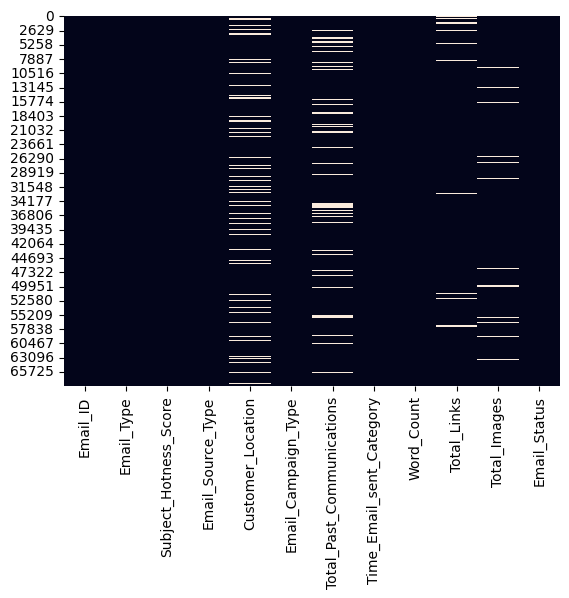

In [ ]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

### What did you know about your dataset?

There are 68353 rows and 12 columns in this dataset.
There are missing values in some columns.The missing values in some columns are:

Customer_Location	: 11595

Total_Past_Communications :	6825

Total_Links :	2201

Total_Images :	1677



## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['Email_ID', 'Email_Type', 'Subject_Hotness_Score', 'Email_Source_Type',
       'Customer_Location', 'Email_Campaign_Type', 'Total_Past_Communications',
       'Time_Email_sent_Category', 'Word_Count', 'Total_Links', 'Total_Images',
       'Email_Status'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,Email_Type,Subject_Hotness_Score,Email_Source_Type,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status
count,68353.000000,68353.000000,68353.000000,68353.000000,61528.000000,68353.000000,68353.000000,66152.000000,66676.000000,68353.000000
mean,1.285094,1.095481,1.456513,2.272234,28.933250,1.999298,699.931751,10.429526,3.550678,0.230934
std,0.451462,0.997578,0.498109,0.468680,12.536518,0.631103,271.719440,6.383270,5.596983,0.497032
min,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,40.000000,1.000000,0.000000,0.000000
25%,1.000000,0.200000,1.000000,2.000000,20.000000,2.000000,521.000000,6.000000,0.000000,0.000000
50%,1.000000,0.800000,1.000000,2.000000,28.000000,2.000000,694.000000,9.000000,0.000000,0.000000
75%,2.000000,1.800000,2.000000,3.000000,38.000000,2.000000,880.000000,14.000000,5.000000,0.000000
max,2.000000,5.000000,2.000000,3.000000,67.000000,3.000000,1316.000000,49.000000,45.000000,2.000000


### Variables Description

Email_ID : A unique identifier assigned to each email in the campaign. It helps track individual email entries.

Email_Type: Denotes the category or format of the email sent.

Subject_Hotness_Score : Represents the estimated effectiveness or appeal of the email subject line, likely based on engagement predictions or past performance.

Email_Source_Type :  Indicates the source system or type used to create/send the email.

Customer_Location : Encodes the geographic location or regional segment of the custom.

Email_Campaign_Type : Indicates the type of email campaign, such as product launch, newsletter, offer, or update.

Total_Past_Communications : Total number of prior email communications sent to the customer before the current one.

Time_Email_sent_Category : Represents the time category in which the email was sent.

Word_Count : Number of words in the body of the email.

Total_Links : Total number of hyperlinks included in the email.

Total_Images : Total number of images embedded in the email.

Email_Status : Indicates whether the email was successful (e.g., opened, clicked) or not.






### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique()

,0
Email_ID,68353
Email_Type,2
Subject_Hotness_Score,51
Email_Source_Type,2
Customer_Location,7
Email_Campaign_Type,3
Total_Past_Communications,64
Time_Email_sent_Category,3
Word_Count,151
Total_Links,37


In [ ]:
df["Email_Type"].unique()

array([1, 2])

In [ ]:
df["Email_Status"].unique()

array([0, 1, 2])

## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68353 entries, 0 to 68352
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Email_ID                   68353 non-null  object 
 1   Email_Type                 68353 non-null  int64  
 2   Subject_Hotness_Score      68353 non-null  float64
 3   Email_Source_Type          68353 non-null  int64  
 4   Customer_Location          56758 non-null  object 
 5   Email_Campaign_Type        68353 non-null  int64  
 6   Total_Past_Communications  61528 non-null  float64
 7   Time_Email_sent_Category   68353 non-null  int64  
 8   Word_Count                 68353 non-null  int64  
 9   Total_Links                66152 non-null  float64
 10  Total_Images               66676 non-null  float64
 11  Email_Status               68353 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 6.3+ MB


In [ ]:
#Handling missing values
df.isnull().sum()

,0
Email_ID,0
Email_Type,0
Subject_Hotness_Score,0
Email_Source_Type,0
Customer_Location,11595
Email_Campaign_Type,0
Total_Past_Communications,6825
Time_Email_sent_Category,0
Word_Count,0
Total_Links,2201


In [ ]:
# Convert float counts to nullable integers
df["Total_Past_Communications"] = df["Total_Past_Communications"].astype("Int64")
df["Total_Links"] = df["Total_Links"].astype("Int64")
df["Total_Images"] = df["Total_Images"].astype("Int64")

In [ ]:
df["Customer_Location"].fillna(df["Customer_Location"].mode()[0],inplace=True)
df["Total_Past_Communications"].fillna(df["Total_Past_Communications"].median(),inplace=True)
df["Total_Links"].fillna(df["Total_Links"].median(),inplace=True)
df["Total_Images"].fillna(df["Total_Images"].median(),inplace=True)

In [ ]:
df.isnull().sum()

,0
Email_ID,0
Email_Type,0
Subject_Hotness_Score,0
Email_Source_Type,0
Customer_Location,0
Email_Campaign_Type,0
Total_Past_Communications,0
Time_Email_sent_Category,0
Word_Count,0
Total_Links,0


### What all manipulations have you done and insights you found?

Filled the missing values and changed the datatypes according to the requirement.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [ ]:
# Map Email_Status labels
email_status_map = {
    0: "Not Opened",
    1: "Opened Only",
    2: "Opened & Clicked"
}

df["Email_Status_Label"] = df["Email_Status"].map(email_status_map)

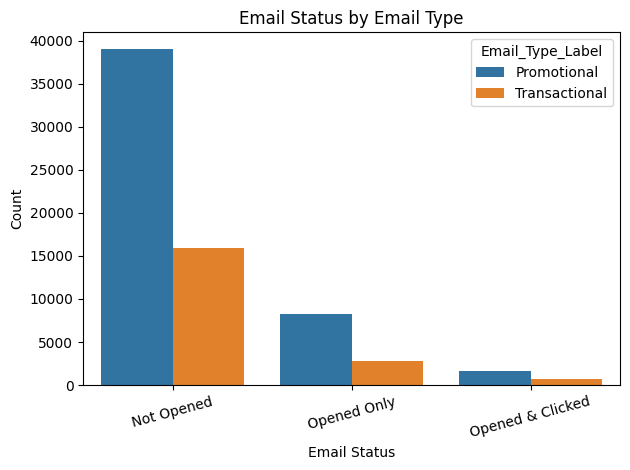

In [ ]:
# Chart - 1 visualization code
# Create temporary labeled versions (for plotting)
type_labels = {
    1: "Promotional",
    2: "Transactional"
}
# Use `map()` for graph labels only
df_plot = df.copy()
df_plot["Email_Type_Label"] = df_plot["Email_Type"].map(type_labels)
# Example: Bar plot
sns.countplot(data=df_plot, x="Email_Status_Label", hue="Email_Type_Label")
plt.title("Email Status by Email Type")
plt.xlabel("Email Status")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is ideal here because it clearly compares email engagement levels (Email_Status) across different email types, making it easy to spot patterns in user response behavior. It effectively visualizes categorical vs. categorical data.

##### 2. What is/are the insight(s) found from the chart?

The number of not opened Emails are more for Promotional Email types.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Transactional emails have a relatively higher engagement rate (more opens and clicks proportionally).This suggests they are more relevant or trusted, and the business can benefit by using a transactional tone or format even in promotional messages.

A large number of promotional emails are not opened, indicating email fatigue or poor targeting.
Continuing this strategy without optimization may lead to lower engagement, unsubscribes, and diminished brand value.

#### Chart - 2

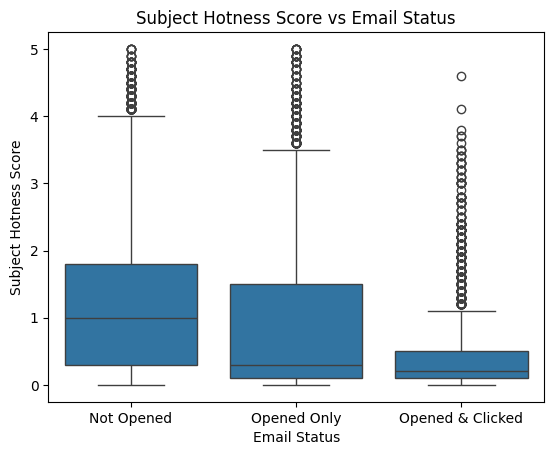

In [ ]:
# Chart - 2 visualization code
#Relation between Subject_Hotness_Score and Email_Status

# Plot
sns.boxplot(data=df, x="Email_Status_Label", y="Subject_Hotness_Score")
plt.title("Subject Hotness Score vs Email Status")
plt.xlabel("Email Status")
plt.ylabel("Subject Hotness Score")
plt.show()

##### 1. Why did you pick the specific chart?

This boxplot was chosen because it clearly shows the distribution and median of Subject_Hotness_Score across different Email_Status categories, helping to visually compare how subject line effectiveness varies with user engagement (opened, clicked, or ignored).

##### 2. What is/are the insight(s) found from the chart?

* "Not Opened" emails have the highest median and a wider spread of Subject Hotness Scores.

* "Opened Only" emails have a slightly lower median and a tighter distribution.

* "Opened & Clicked" emails show the lowest subject hotness scores, mostly clustered near 0–0.5, with many outliers.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Subject Hotness Score does not correlate positively with higher engagement.

Marketers should test simpler or more authentic subject lines, rather than relying on high "hotness" scores.

#### Chart - 3

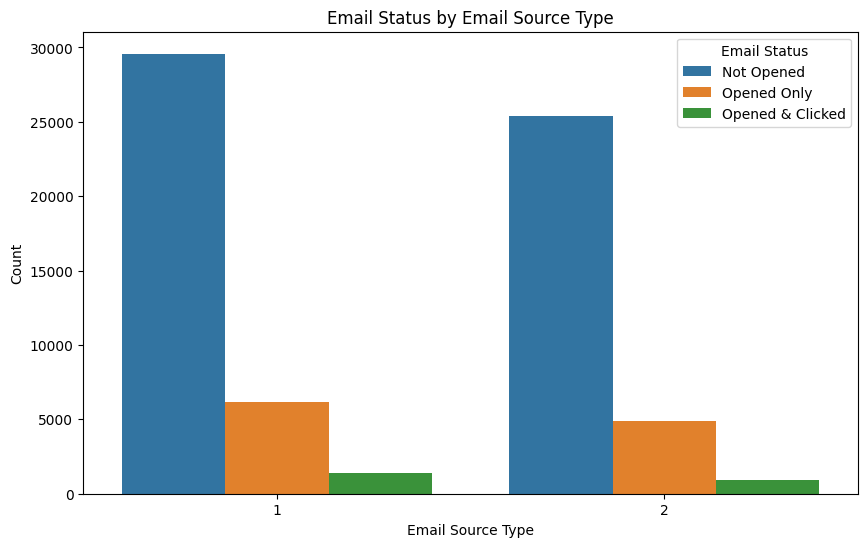

In [ ]:
# Chart - 3 visualization code
#Relation between Email_Source_Type and Email_Status
# Plot
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Email_Source_Type", hue="Email_Status_Label")
plt.title("Email Status by Email Source Type")
plt.xlabel("Email Source Type")
plt.ylabel("Count")
plt.legend(title="Email Status")
plt.show()

In [ ]:
df.columns

Index(['Email_ID', 'Email_Type', 'Subject_Hotness_Score', 'Email_Source_Type',
       'Customer_Location', 'Email_Campaign_Type', 'Total_Past_Communications',
       'Time_Email_sent_Category', 'Word_Count', 'Total_Links', 'Total_Images',
       'Email_Status', 'Email_Status_Label'],
      dtype='object')

##### 1. Why did you pick the specific chart?

This grouped bar plot (countplot) is ideal because it:

* Compares two categorical variables (Email_Source_Type and Email_Status) effectively.

* Clearly shows engagement differences (opened, clicked) across email sources.

* Helps identify which source performs better, guiding future campaign strategies.

##### 2. What is/are the insight(s) found from the chart?

Email_Source_Type 1 has more number of Not Opened emails as compared to Type 2.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

If the Email is sent using the source 1 there is more chances of it to not get Opened. While sending the Email it is more important to check the suitable Sources for sending the mail.

#### Chart - 4

In [ ]:
df.columns

Index(['Email_ID', 'Email_Type', 'Subject_Hotness_Score', 'Email_Source_Type',
       'Customer_Location', 'Email_Campaign_Type', 'Total_Past_Communications',
       'Time_Email_sent_Category', 'Word_Count', 'Total_Links', 'Total_Images',
       'Email_Status', 'Email_Status_Label'],
      dtype='object')

In [ ]:
df["Customer_Location"].unique()

array(['E', 'G', 'B', 'C', 'D', 'F', 'A'], dtype=object)

In [ ]:
# Chart - 4 visualization code
#Relation between Customer_Location and Email_Status
fig = px.histogram(
    df,
    x="Customer_Location",
    color="Email_Status_Label",
    barmode="group",
    title="Email Status by Customer Location",
    labels={"Email_Status_Label": "Email Status"},
)
fig.update_layout(xaxis_title="Customer Location", yaxis_title="Count")
fig.show()

##### 1. Why did you pick the specific chart?

The Grouped Bar Chart (Plotly Express) is chosen because it:

* Clearly compares engagement levels (Email_Status) across multiple Customer_Locations side by side.

* Is interactive, allowing users to hover and explore data details.

* Helps quickly spot which locations perform better or worse in terms of opens and clicks.

##### 2. What is/are the insight(s) found from the chart?

The number of Not Opened Emails in Location G are the highest.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The chart shows that Customer Location G has the highest number of emails sent but also the highest count of unopened emails, indicating low engagement. In contrast, locations like E and D show relatively better open and click rates, suggesting higher engagement in those regions. This insight can help target specific regions with improved or customized email strategies.

#### Chart - 5

In [ ]:
df.columns

Index(['Email_ID', 'Email_Type', 'Subject_Hotness_Score', 'Email_Source_Type',
       'Customer_Location', 'Email_Campaign_Type', 'Total_Past_Communications',
       'Time_Email_sent_Category', 'Word_Count', 'Total_Links', 'Total_Images',
       'Email_Status', 'Email_Status_Label'],
      dtype='object')

In [ ]:
# Chart - 5 visualization code
#Relation between Email_Campaign_Type and Email_Status
fig = px.histogram(
    df,
    x="Email_Campaign_Type",
    color="Email_Status_Label",
    barmode="group",
    title="Email Status by Campaign Type",
    labels={"Email_Campaign_Type": "Campaign Type", "Email_Status_Label": "Email Status"}
)
fig.show()

##### 1. Why did you pick the specific chart?

This graph is chosen because it clearly shows the count of not opened, openend only and opened & click mails together along with the campaign types.

##### 2. What is/are the insight(s) found from the chart?

The number of not openend mails are highest in campaign 2 while the ratio of not opened emails are less in campaign 2 and opened emails are also higher.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, increasing the number of emails in campaign type 3 can result in high engagement of the users.

#### Chart - 6

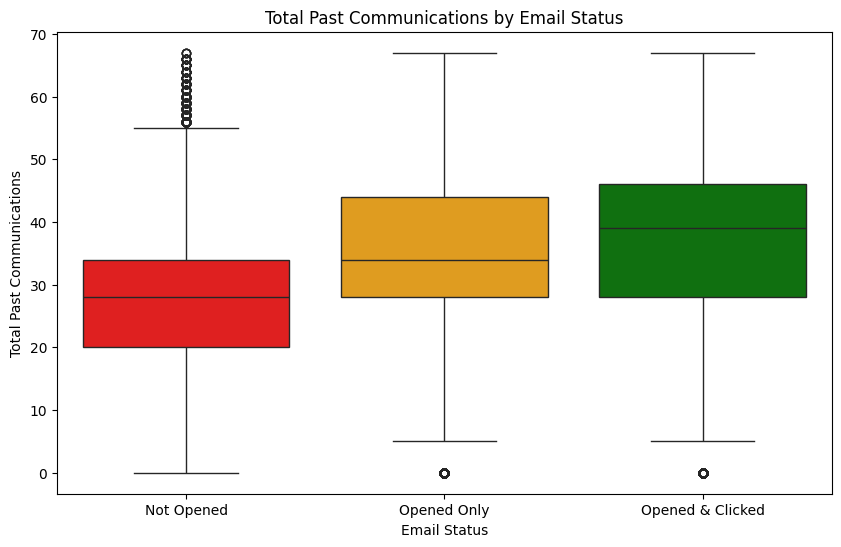

In [ ]:
# Chart - 6 visualization code
#Relation between Total_Past_Communications and Not Openend Emails
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Email_Status_Label", y="Total_Past_Communications", palette=["red", "orange", "green"])
plt.title("Total Past Communications by Email Status")
plt.xlabel("Email Status")
plt.ylabel("Total Past Communications")
plt.show()


##### 1. Why did you pick the specific chart?

A boxplot is ideal for comparing the distribution of a numeric variable (Total_Past_Communications) across multiple categories (Email_Status_Label). It shows the median, spread, and outliers, giving a clear view of central tendency and variability.



##### 2. What is/are the insight(s) found from the chart?

Customers who had more past communications tend to open and click more emails, while those with fewer past communications are more likely to ignore emails.
This suggests a positive correlation between prior engagement and email interaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, insights show that higher past communications increase email engagement, which can help optimize targeting for better results.
However, high unopened rates suggest poor targeting or content, which may reduce effectiveness and harm brand perception if not improved.



#### Chart - 7

In [ ]:
df["Time_Email_sent_Category"].unique()

array([1, 2, 3])

In [ ]:
# Define meaningful time labels for plotting
time_labels = {
    1: "Morning",
    2: "Afternoon",
    3: "Evening"
}

# Map the labels (only for visualization)
df["Time_Label"] = df["Time_Email_sent_Category"].map(time_labels)


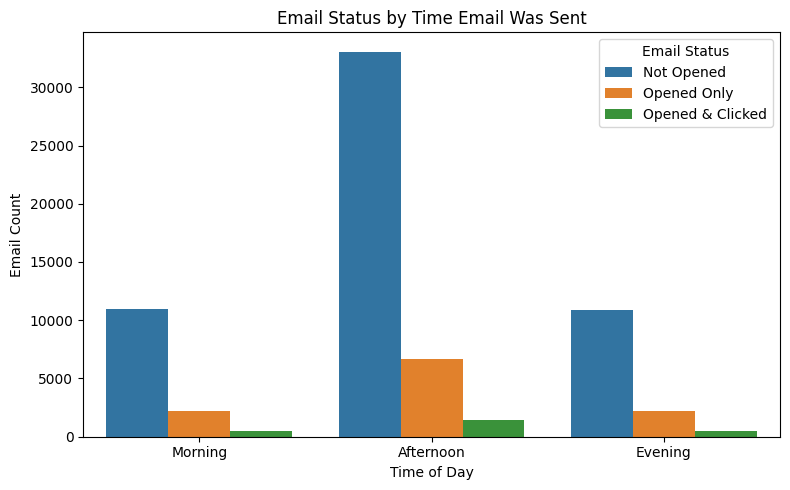

In [ ]:
# Chart - 7 visualization code
#Relation between Time_Email_sent_Category and Email_Status
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Time_Label", hue="Email_Status_Label")
plt.title("Email Status by Time Email Was Sent")
plt.xlabel("Time of Day")
plt.ylabel("Email Count")
plt.legend(title="Email Status")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This grouped bar chart is effective for comparing email engagement (status) across different time categories in a clear and segmented way.

##### 2. What is/are the insight(s) found from the chart?

Most emails sent in the afternoon remain not opened, while morning and evening emails show relatively better engagement (higher open and click rates).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights support a positive business impact by indicating that shifting email campaigns to morning or evening could improve engagement.
However, continuing to send most emails in the afternoon without improvement could contribute to negative growth due to consistently poor response.

#### Chart - 8

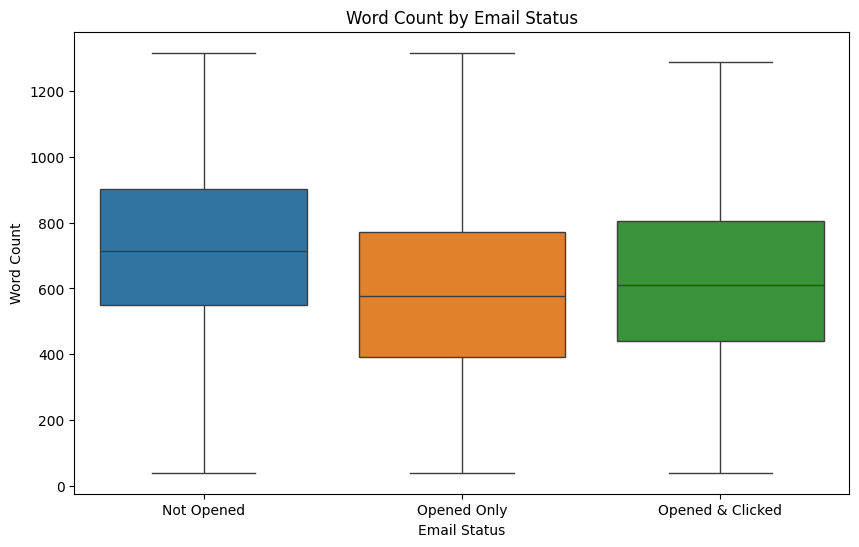

In [ ]:
# Chart - 8 visualization code
#Relation between Word_Count and Email_Status
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Email_Status_Label', y='Word_Count', palette=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Word Count by Email Status')
plt.xlabel('Email Status')
plt.ylabel('Word Count')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot effectively visualizes the distribution, median, and spread of word counts across different email statuses, highlighting patterns and outliers clearly.

##### 2. What is/are the insight(s) found from the chart?

Emails with fewer words tend to perform better (higher open and click rates), while long emails are more common among those not opened, indicating that shorter content may be more engaging.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Business impact:
Yes, these insights can positively impact business by helping design concise emails that are more likely to be opened and clicked, improving engagement rates.

Possible negative insight:
Overly long emails may discourage user interaction, leading to reduced open rates and missed communication opportunities.

#### Chart - 9

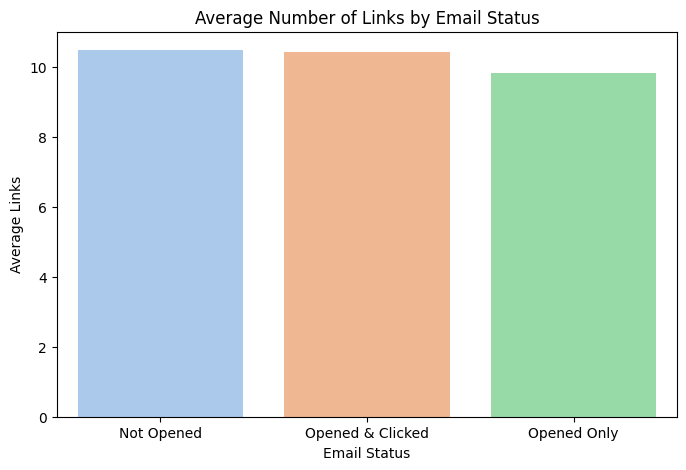

In [ ]:
# Chart - 9 visualization code
#Relation between Total_Links and Email_Status
avg_links = df.groupby("Email_Status_Label")["Total_Links"].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_links, x="Email_Status_Label", y="Total_Links", palette="pastel")
plt.title("Average Number of Links by Email Status")
plt.xlabel("Email Status")
plt.ylabel("Average Links")
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is ideal for comparing average values across categories. It clearly shows how the average number of links differs between email statuses (e.g., Not Opened, Opened, Clicked).

##### 2. What is/are the insight(s) found from the chart?

Emails that were opened only have the lowest average number of links, while both not opened and opened & clicked emails have slightly higher link counts, suggesting a non-linear relationship between link count and engagement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. These insights can guide marketers to strategically balance the number of links—possibly keeping them lower to improve open rates, but relevant and actionable to encourage clicks.

#### Chart - 10

In [ ]:
df.columns

Index(['Email_ID', 'Email_Type', 'Subject_Hotness_Score', 'Email_Source_Type',
       'Customer_Location', 'Email_Campaign_Type', 'Total_Past_Communications',
       'Time_Email_sent_Category', 'Word_Count', 'Total_Links', 'Total_Images',
       'Email_Status', 'Email_Status_Label', 'Time_Label'],
      dtype='object')

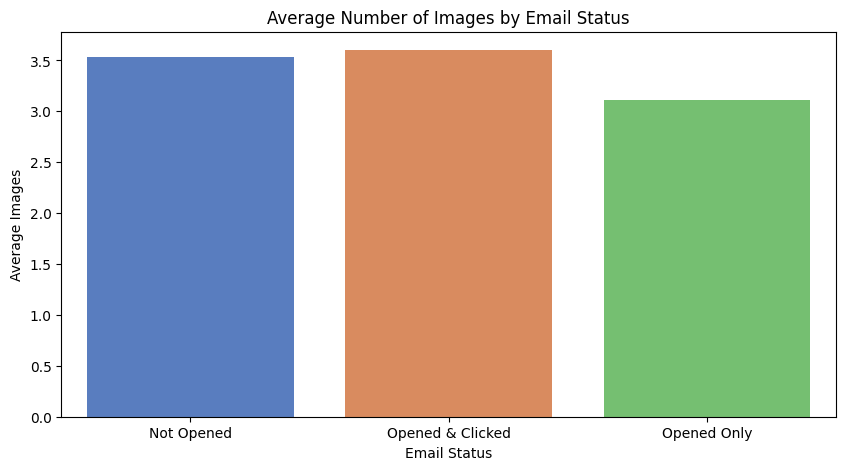

In [ ]:
# Chart - 10 visualization code
#Relation between Total_Images and Email_Status
avg_images = df.groupby("Email_Status_Label")["Total_Images"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=avg_images, x="Email_Status_Label", y="Total_Images", palette="muted")
plt.title("Average Number of Images by Email Status")
plt.xlabel("Email Status")
plt.ylabel("Average Images")
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing average values across categories. It clearly highlights differences in the average number of images across email engagement levels.



##### 2. What is/are the insight(s) found from the chart?

* Emails that were Opened & Clicked have the highest average number of images.

* Emails that were Opened Only had the lowest average number of images.

* Surprisingly, even Not Opened emails had more images than those just opened.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights suggest that more images can boost clicks, helping optimize email design. However, high images in unopened emails show visuals alone don't drive opens—subject lines and timing may matter more.

#### Chart - 11

In [ ]:
df.drop(columns=["Email_Status_Label","Time_Label"],inplace=True)

In [ ]:
int_columns_df = df.select_dtypes(include = ['int','float'])
int_columns_df.head()

,Email_Type,Subject_Hotness_Score,Email_Source_Type,Email_Campaign_Type,Total_Past_Communications,Time_Email_sent_Category,Word_Count,Total_Links,Total_Images,Email_Status
0,1,2.2,2,2,33,1,440,8,0,0
1,2,2.1,1,2,15,2,504,5,0,0
2,2,0.1,1,3,36,2,962,5,0,1
3,1,3.0,2,2,25,2,610,16,0,0
4,1,0.0,2,3,18,2,947,4,0,0


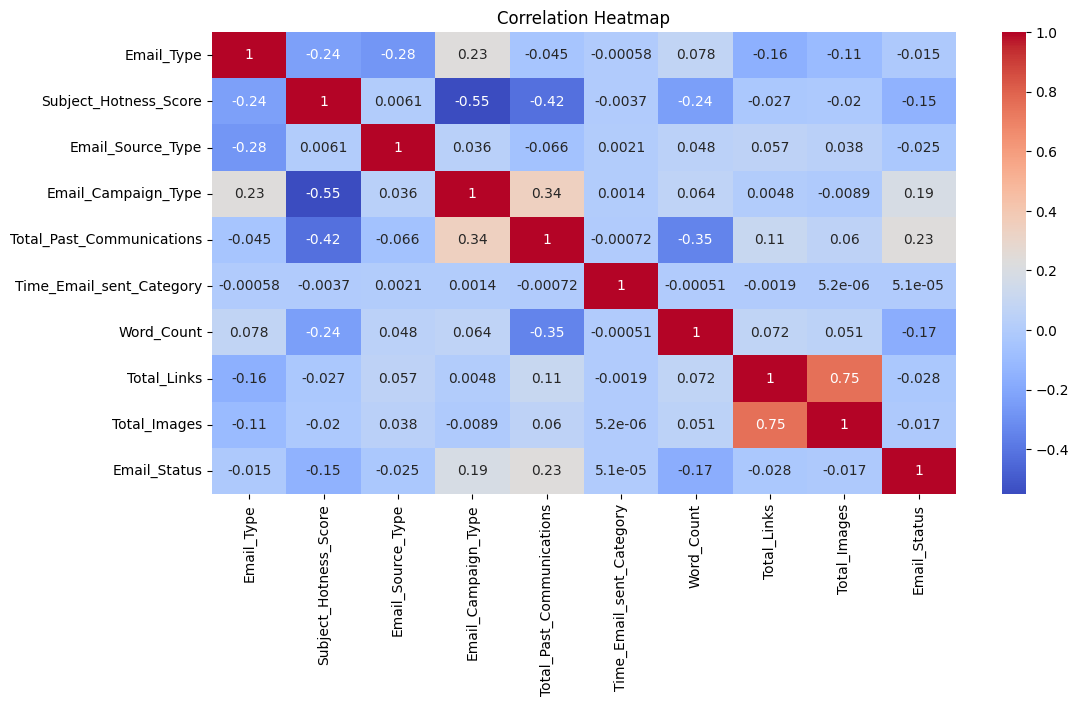

In [ ]:
# Heatmap plot for correlation between different variable
plt.figure(figsize=(12, 6))
sns.heatmap(int_columns_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap visually represents the strength and direction of relationships between variables. It quickly highlights positive, negative, or no correlations, aiding in data understanding and feature selection for modeling.

##### 2. What is/are the insight(s) found from the chart?

Key insights include a strong positive correlation between Total_Links and Total_Images (0.75), indicating they often appear together. Email_Campaign_Type and Total_Past_Communications show positive correlations with Email_Status (0.19 and 0.23), suggesting their influence on engagement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Businesses should focus on optimal campaign types and consistent communication to improve email status. While more links/images co-occur, their slight negative correlation with email status suggests testing for an optimal balance to avoid overwhelming recipients and ensure better engagement.

#### Chart - 12

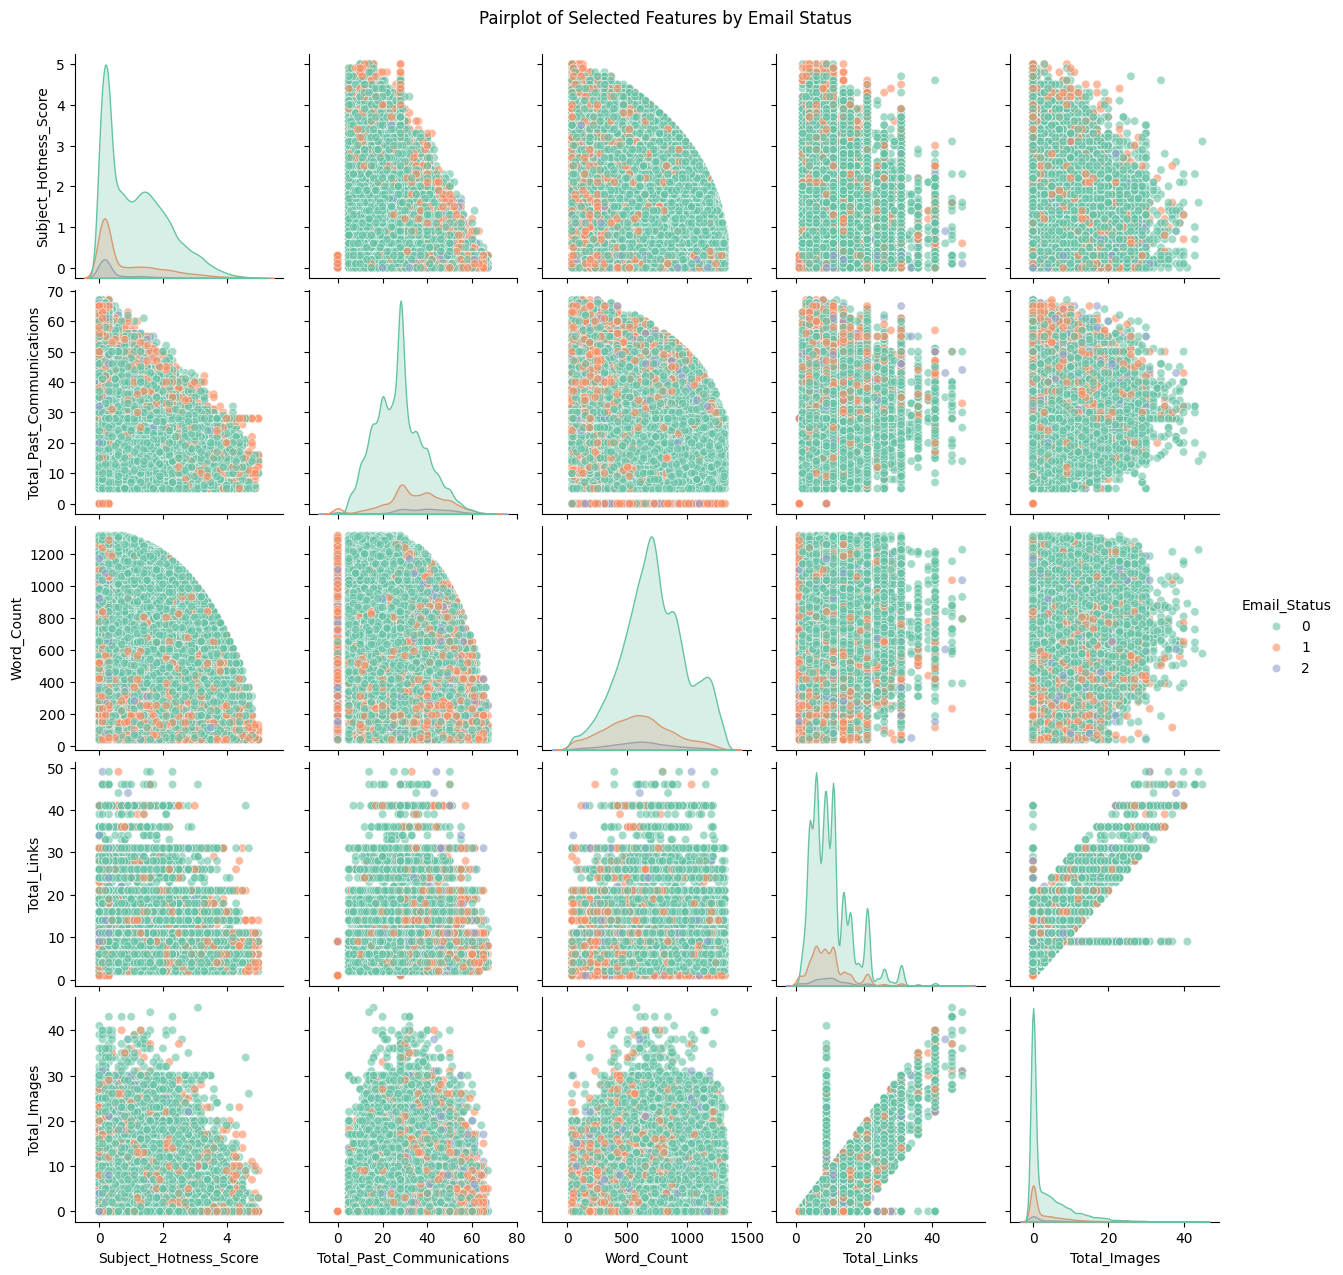

In [ ]:
# Chart - 12 visualization code
#Pair Plot
# Select numeric features to compare with Not_Opened_Flag
selected_cols = [
    'Email_Status','Subject_Hotness_Score', 'Total_Past_Communications',
    'Word_Count', 'Total_Links', 'Total_Images'
]

# Drop NaNs to avoid plotting issues
df_subset = df[selected_cols].dropna()

# Create the pairplot
sns.pairplot(df_subset, hue='Email_Status', palette='Set2', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle("Pairplot of Selected Features by Email Status", y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot visualizes the univariate distribution of each variable (on the diagonal) and the pairwise relationships between all variables (off-diagonal scatter plots). It helps quickly identify trends, clusters, and the separability of different categories within the data.

##### 2. What is/are the insight(s) found from the chart?

The plot shows that Total_Links and Total_Images are highly correlated. However, the different Email_Status categories (0, 1, 2) are heavily intermingled across all feature pairs, indicating no single feature or simple combination clearly separates them. Most features like Subject_Hotness_Score, Total_Past_Communications, Word_Count, Total_Links, and Total_Images are skewed towards lower values.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Since Email_Status categories overlap significantly, predicting email status likely requires more complex models than simple rule-based approaches. Businesses should note the common content patterns (e.g., fewer links/images, lower word counts) and analyze if this aligns with desired engagement. Further segmentation might reveal clearer patterns for targeted strategies.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum()

,0
Email_ID,0
Email_Type,0
Subject_Hotness_Score,0
Email_Source_Type,0
Customer_Location,0
Email_Campaign_Type,0
Total_Past_Communications,0
Time_Email_sent_Category,0
Word_Count,0
Total_Links,0


### 2. Handling Outliers

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68353 entries, 0 to 68352
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Email_ID                   68353 non-null  object 
 1   Email_Type                 68353 non-null  int64  
 2   Subject_Hotness_Score      68353 non-null  float64
 3   Email_Source_Type          68353 non-null  int64  
 4   Customer_Location          68353 non-null  object 
 5   Email_Campaign_Type        68353 non-null  int64  
 6   Total_Past_Communications  68353 non-null  Int64  
 7   Time_Email_sent_Category   68353 non-null  int64  
 8   Word_Count                 68353 non-null  int64  
 9   Total_Links                68353 non-null  Int64  
 10  Total_Images               68353 non-null  Int64  
 11  Email_Status               68353 non-null  int64  
dtypes: Int64(3), float64(1), int64(6), object(2)
memory usage: 6.5+ MB


In [ ]:
# Handling Outliers & Outlier treatments
columns = ['Subject_Hotness_Score', 'Total_Past_Communications', 'Word_Count', 'Total_Links', 'Total_Images']
def check_outliers(columns, data):
    for col in columns:
        plt.figure(figsize=(5, 4))
        sns.boxplot(y=data[col])
        plt.title(f'Boxplot for {col}')
        plt.ylabel(col)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

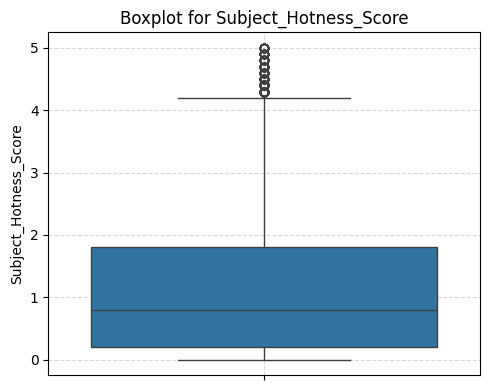

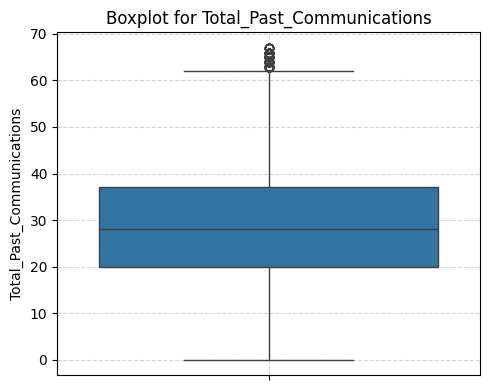

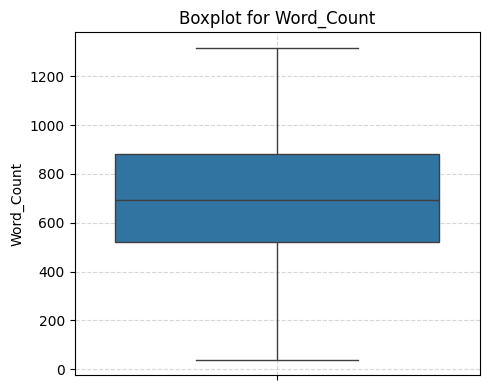

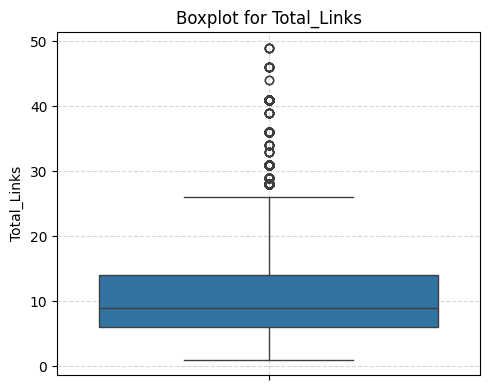

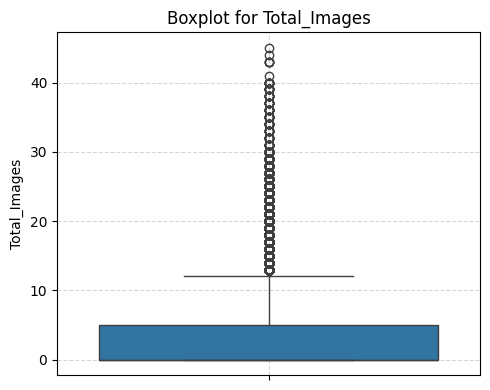

In [ ]:
# Plot the graph
check_outliers(columns,df)

In [ ]:
#Handling outliers
def handle_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        # Define bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Convert bounds to integer for Int64 columns
        if df[col].dtype == 'Int64':
            lower_bound = int(lower_bound)
            upper_bound = int(upper_bound)


        # Cap outliers (Winsorization)
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    return df

In [ ]:
columns = ['Subject_Hotness_Score', 'Total_Past_Communications', 'Word_Count', 'Total_Links', 'Total_Images']
df = handle_outliers_iqr(df, columns)


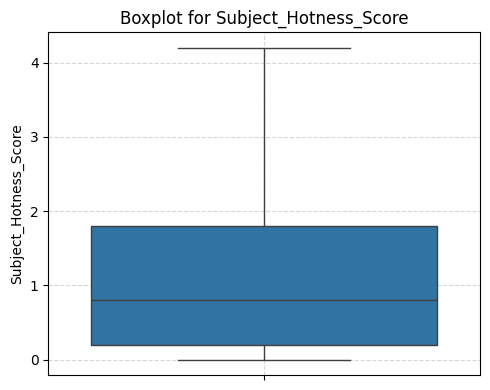

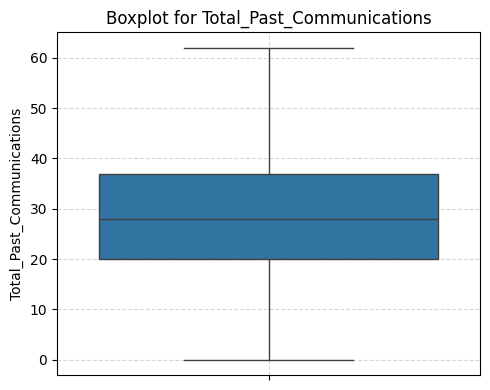

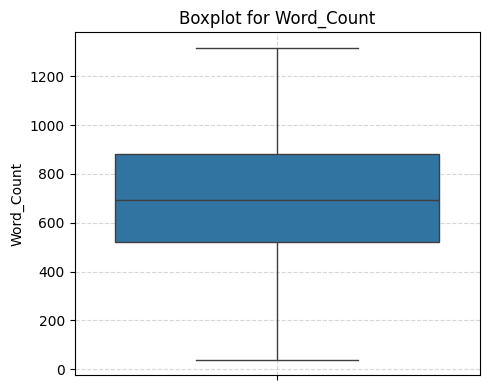

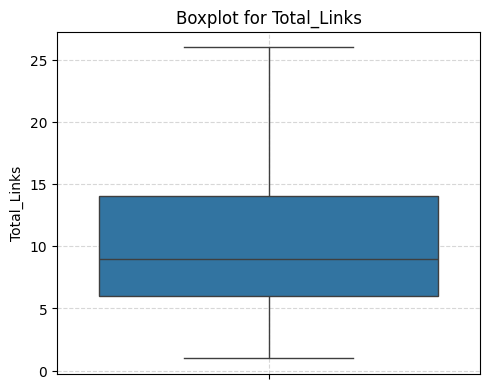

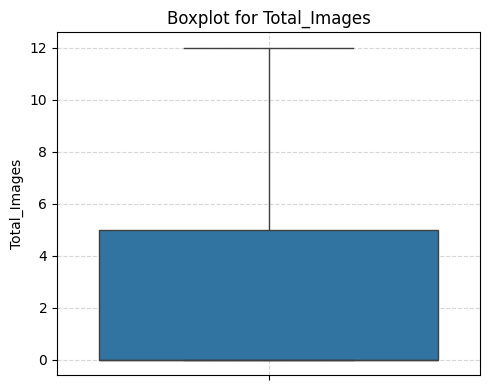

In [ ]:
#plot ouliers
check_outliers(columns,df)

##### What all outlier treatment techniques have you used and why did you use those techniques?

Used IQR-based capping (Winsorization) to treat outliers, which limits extreme values without removing data. This helps reduce skew and keeps important patterns intact—ideal for email metrics like links, word count, and images.

### 3. Categorical Encoding

In [ ]:
df.columns

Index(['Email_ID', 'Email_Type', 'Subject_Hotness_Score', 'Email_Source_Type',
       'Customer_Location', 'Email_Campaign_Type', 'Total_Past_Communications',
       'Time_Email_sent_Category', 'Word_Count', 'Total_Links', 'Total_Images',
       'Email_Status'],
      dtype='object')

In [ ]:
# Encode your categorical columns
# One-Hot Encoding for all categorical variables (for logistic regression)
categorical_cols = ['Email_Type', 'Email_Source_Type', 'Customer_Location',
                    'Email_Campaign_Type', 'Time_Email_sent_Category']

df= pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [ ]:
df.columns

Index(['Email_ID', 'Subject_Hotness_Score', 'Total_Past_Communications',
       'Word_Count', 'Total_Links', 'Total_Images', 'Email_Status',
       'Email_Type_2', 'Email_Source_Type_2', 'Customer_Location_B',
       'Customer_Location_C', 'Customer_Location_D', 'Customer_Location_E',
       'Customer_Location_F', 'Customer_Location_G', 'Email_Campaign_Type_2',
       'Email_Campaign_Type_3', 'Time_Email_sent_Category_2',
       'Time_Email_sent_Category_3'],
      dtype='object')

#### What all categorical encoding techniques have you used & why did you use those techniques?

One-Hot Encoding is used here for nominal categorical features to avoid introducing false order or bias in the model. This is ideal for Logistic Regression, as it treats each category independently and improves model accuracy.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
# Reduce multicollinearity
df['Total_Media'] = df['Total_Links'] + df['Total_Images']
df.drop(['Total_Links', 'Total_Images'], axis=1, inplace=True)

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
# Define predictor variables and target variable
X = df.drop(columns=['Email_Status'])
y = df['Email_Status']

# Save all feature names as list
feature_cols = X.columns.tolist()


Email_Status
0    0.803783
1    0.161500
2    0.034717
Name: proportion, dtype: float64


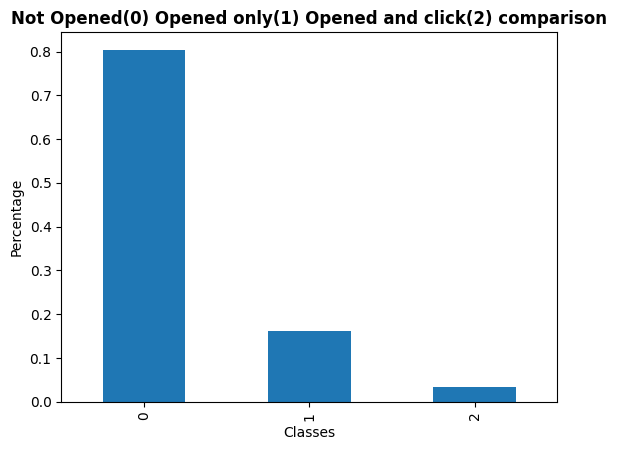

In [ ]:
# Check target classes balance
status = df['Email_Status'].value_counts(normalize=True)
print(status)

# Plot the classes
status.plot(kind = 'bar')
plt.title('Not Opened(0) Opened only(1) Opened and click(2) comparison',fontweight = "bold")
plt.xlabel('Classes')
plt.ylabel('Percentage')
plt.show()

### 6. Data Scaling

In [ ]:
# Scaling your data
# Select numerical columns
num_cols = ['Subject_Hotness_Score', 'Total_Past_Communications', 'Word_Count', 'Total_Media']

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

##### Which method have you used to scale you data and why?

I used StandardScaler from sklearn.preprocessing to scale the data. This method standardizes features by removing the mean and scaling to unit variance (z-score normalization).



### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(X,y,test_size = 0.3,random_state = 0)


In [ ]:
# Shape of the train and test data
print('Shape of X_train:{}'.format(X_train.shape))
print('Shape of y_train:{}'.format(y_train.shape))
print('Shape of X_test:{}'.format(X_test.shape))
print('Shape of y_test:{}'.format(y_test.shape))

Shape of X_train:(47847, 17)
Shape of y_train:(47847,)
Shape of X_test:(20506, 17)
Shape of y_test:(20506,)


##### What data splitting ratio have you used and why?

A 70:30 train-test split was used.
* 70% for training ensures the model has enough data to learn patterns effectively.

* 30% for testing provides a sufficient and unbiased dataset to evaluate model performance.

* This ratio is a common standard that balances training accuracy and validation reliability.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The data is imbalanced because the number of not opened emails are very high as compared to opened only and opened&click ones.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68353 entries, 0 to 68352
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Email_ID                    68353 non-null  object 
 1   Subject_Hotness_Score       68353 non-null  float64
 2   Total_Past_Communications   68353 non-null  float64
 3   Word_Count                  68353 non-null  float64
 4   Email_Status                68353 non-null  int64  
 5   Email_Type_2                68353 non-null  bool   
 6   Email_Source_Type_2         68353 non-null  bool   
 7   Customer_Location_B         68353 non-null  bool   
 8   Customer_Location_C         68353 non-null  bool   
 9   Customer_Location_D         68353 non-null  bool   
 10  Customer_Location_E         68353 non-null  bool   
 11  Customer_Location_F         68353 non-null  bool   
 12  Customer_Location_G         68353 non-null  bool   
 13  Email_Campaign_Type_2       683

In [ ]:
## set id column as index
df.set_index("Email_ID",inplace = True)

#print first i rows
df.head(1)

,Subject_Hotness_Score,Total_Past_Communications,Word_Count,Email_Status,Email_Type_2,Email_Source_Type_2,Customer_Location_B,Customer_Location_C,Customer_Location_D,Customer_Location_E,Customer_Location_F,Customer_Location_G,Email_Campaign_Type_2,Email_Campaign_Type_3,Time_Email_sent_Category_2,Time_Email_sent_Category_3,Total_Media
Email_ID,,,,,,,,,,,,,,,,,
EMA00081000034500,1.112777,0.350467,-0.956625,0,False,True,False,False,False,True,False,False,True,False,False,False,-0.566329


In [ ]:
# Handling Imbalanced Dataset (If needed)
# Using SMOTE
from imblearn.over_sampling import SMOTE

print('Dataset Before:',y_train.value_counts())
smt = SMOTE()

# Drop the 'Email_ID' column from X_train and X_test
X_train_fixed = X_train.drop(columns=['Email_ID']).copy()
X_test_fixed = X_test.drop(columns=['Email_ID']).copy()

# Convert Int64 columns to float64 for SMOTE
int64_cols = X_train_fixed.select_dtypes(include='Int64').columns
X_train_fixed[int64_cols] = X_train_fixed[int64_cols].astype('float64')


# fit predictor and target variable
X_train_smt, y_train_smt = smt.fit_resample(X_train_fixed,y_train)

print('\nDataset After:',y_train_smt.value_counts())

Dataset Before: Email_Status
0    38438
1     7733
2     1676
Name: count, dtype: int64

Dataset After: Email_Status
0    38438
1    38438
2    38438
Name: count, dtype: int64


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

To handle the imbalanced dataset, SMOTE (Synthetic Minority Over-sampling Technique) was used because:
* It generates synthetic examples for minority classes instead of duplicating, reducing overfitting.

* Helps balance the class distribution, improving model performance—especially for recall and F1-score on underrepresented classes.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation
# Fit the Algorithm
from sklearn.model_selection import cross_val_score

In [ ]:
#fitting the model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score

# Custom precision scorer to handle division by zero and multiclass
precision = make_scorer(precision_score, average='weighted', zero_division=0)

# Logistic regression model with increased iterations
logistic_regression = LogisticRegression(max_iter=1000)

# Parameter grid
param_grid = {
    'penalty': ['l2'],
    'C': [0.0001, 0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 10]
}

# Use StratifiedKFold for class balance during cross-validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# GridSearchCV setup, using the custom precision scorer object
logistic_grid_model = GridSearchCV(
    logistic_regression,
    param_grid,
    scoring=precision, # Use the custom precision scorer object
    n_jobs=-1,
    verbose=3,
    cv=cv
)

# Fit the model using the balanced training data
logistic_grid_model.fit(X_train_smt, y_train_smt)

# Output best model info
print("Best Estimator:\n", logistic_grid_model.best_estimator_)
print("\nBest Parameters:\n", logistic_grid_model.best_params_)
print("\nBest Precision Score:\n", logistic_grid_model.best_score_)

Fitting 3 folds for each of 14 candidates, totalling 42 fits
Best Estimator:
 LogisticRegression(C=1, max_iter=1000)

Best Parameters:
 {'C': 1, 'penalty': 'l2'}

Best Precision Score:
 0.6061069007779155


In [ ]:
# Best estimator
logistic_grid_model.best_estimator_

LogisticRegression(C=1, max_iter=1000)

In [ ]:
# Best parameters
logistic_grid_model.best_params_

{'C': 1, 'penalty': 'l2'}

In [ ]:
# Best score
logistic_grid_model.best_score_

np.float64(0.6061069007779155)

In [ ]:
# Predicted results
y_train_pred = logistic_grid_model.predict(X_train_smt)
y_test_pred = logistic_grid_model.predict(X_test_fixed)

In [ ]:
# Importing important matrices
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix

In [ ]:
# Training and testing accuracy
train_accuracy = accuracy_score(y_train_pred, y_train_smt)
test_accuracy = accuracy_score(y_test_pred,y_test)

print('Training accuracy:', train_accuracy)
print('Testing accuracy:', test_accuracy)

Training accuracy: 0.6129004283955114
Testing accuracy: 0.6897493416561007


In [ ]:
# Get scores like precision,recall, f1 score,roc_auc_score, confusion matrix
  # precision,
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# Precision
log_test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)

# Recall
log_test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)

# F1 Score
log_f1_score = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

# ROC AUC Score (for multiclass)
log_roc_auc_score = roc_auc_score(y_test, logistic_grid_model.predict_proba(X_test_fixed),
                                  multi_class='ovr', average='weighted')

# Confusion Matrix
log_confusion_mat = confusion_matrix(y_test, y_test_pred)

# Output
print("Precision score of logistic model:", log_test_precision)
print("\nRecall score of logistic model:", log_test_recall)
print("\nF1 score of logistic model:", log_f1_score)
print("\nROC AUC score of logistic model:", log_roc_auc_score)
print("\nConfusion matrix of logistic model:\n", log_confusion_mat)


labels = ['Not Opened', 'Opened_Only', 'Opened_and_Clicked']

Precision score of logistic model: 0.7295841503291822

Recall score of logistic model: 0.6897493416561007

F1 score of logistic model: 0.7058134792871086

ROC AUC score of logistic model: 0.6588442038168348

Confusion matrix of logistic model:
 [[13339  1542  1622]
 [ 1973   597   736]
 [  384   105   208]]


Logistic Regression model is used here to classify email statuses, using GridSearchCV for hyperparameter tuning. The best model was selected with C=0.01 and l2 regularization, using Stratified K-Fold CV and optimizing for weighted precision.

### ML Model - 2

In [ ]:
# Implementing random forest
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators = 100)
rf_classifier.fit(X_train_smt,y_train_smt)

RandomForestClassifier()

In [ ]:
# class predictions
y_train_rf_pred = rf_classifier.predict(X_train_smt)
y_test_rf_pred = rf_classifier.predict(X_test_fixed)

In [ ]:
# Training and testing accuracy
rf_training_accuracy = accuracy_score(y_train_smt,y_train_rf_pred)
rf_testing_accuracy = accuracy_score(y_test,y_test_rf_pred)

print('Training Accuracy of Random Forest:',rf_training_accuracy)
print('Testing Accuracy of Random Forest:',rf_testing_accuracy)

Training Accuracy of Random Forest: 0.9998439044695353
Testing Accuracy of Random Forest: 0.7864039793231249


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest is a powerful ensemble machine learning algorithm used for classification and regression tasks. It builds multiple decision trees and merges their results to improve accuracy and avoid overfitting.



Precision score of RANDOM FOREST model: 0.7427591594002491
 
Recall score of RANDOM FOREST model: 0.7864039793231249
 
F1 score of RANDOM FOREST model:  0.7595036596804358
 
ROC AUC score of RANDOM FOREST model:  0.7409848939161051
 
Confusion matrix of RANDOM FOREST 
: [[15320  1060   123]
 [ 2427   772   107]
 [  454   209    34]]
 


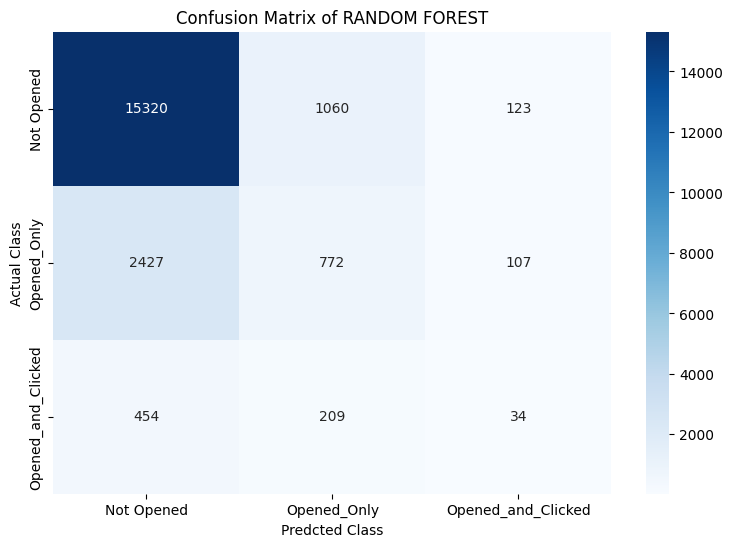

In [ ]:
# Visualizing evaluation Metric Score chart
# Get scores like precision,recall, f1 score,roc_auc_score, confusion matrix
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

# precision,
rf_test_precision = precision_score(y_test,y_test_rf_pred, average='weighted', zero_division=0)

  # recall,
rf_test_recall = recall_score(y_test,y_test_rf_pred, average='weighted', zero_division=0)

  # f1 score
rf_f1_score = f1_score(y_test,y_test_rf_pred, average='weighted', zero_division=0)

  # roc_auc_score
# Use predict_proba for roc_auc_score in multiclass setting
rf_roc_auc_score = roc_auc_score(y_test, rf_classifier.predict_proba(X_test_fixed), multi_class='ovr', average='weighted')

  # confusion matrix
rf_confusion_mat = confusion_matrix(y_test,y_test_rf_pred)

  # Printing all these matrices
print('Precision score of RANDOM FOREST model:',rf_test_precision)
print(' ')
print('Recall score of RANDOM FOREST model:', rf_test_recall)
print(' ')
print('F1 score of RANDOM FOREST model: ', rf_f1_score)
print(' ')
print('ROC AUC score of RANDOM FOREST model: ',rf_roc_auc_score)
print(' ')
print('Confusion matrix of RANDOM FOREST \n:',rf_confusion_mat)
print(' ')
# Correct labels for the confusion matrix visualization
labels = ['Not Opened','Opened_Only','Opened_and_Clicked']

# plotting confusion matrix through heatmap
plt.figure(figsize = (9,6))
sns.heatmap(rf_confusion_mat,cmap = 'Blues', annot = True, fmt='d', xticklabels = labels, yticklabels = labels)
plt.ylabel('Actual Class')
plt.xlabel('Predcted Class')
plt.title('Confusion Matrix of RANDOM FOREST',fontsize = 12)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
params_grid = {'n_estimators' : [100,150],'max_depth' : [10,20]}

In [ ]:
grid_renf_clf = GridSearchCV(RandomForestClassifier(), params_grid, scoring = 'accuracy', n_jobs = -1, verbose = 3, cv = 3)
grid_renf_clf.fit(X_train_smt, y_train_smt)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [10, 20], 'n_estimators': [100, 150]},
             scoring='accuracy', verbose=3)

In [ ]:
# print best score and best params
print(grid_renf_clf.best_score_)
print(grid_renf_clf.best_params_)

0.8402015366737777
{'max_depth': 20, 'n_estimators': 150}


In [ ]:
# Get the predicted classes
y_train_grid_rf_pred = grid_renf_clf.predict(X_train_smt)
y_test_grid_rf_pred = grid_renf_clf.predict(X_test_fixed)

In [ ]:
# Get the accuracy scores
ref_training_accuracy = accuracy_score(y_train_grid_rf_pred,y_train_smt)
ref_testing_accuracy = accuracy_score(y_test_grid_rf_pred,y_test)

print("The accuracy on train data is ", ref_training_accuracy)
print("The accuracy on test data is ", ref_testing_accuracy)

The accuracy on train data is  0.9596666493227188
The accuracy on test data is  0.7847946942358334


Precision score of RANDOM FOREST: 0.7471789114089338
 
Recall score of RANDOM FOREST: 0.7847946942358334
 
F1 score of RANDOM FOREST:  0.7620697806544633
 
ROC AUC score of RANDOM FOREST:  0.7522581228966757
 
Confusion matrix of RANDOM FOREST model 
: [[15225  1099   179]
 [ 2344   819   143]
 [  417   231    49]]
 


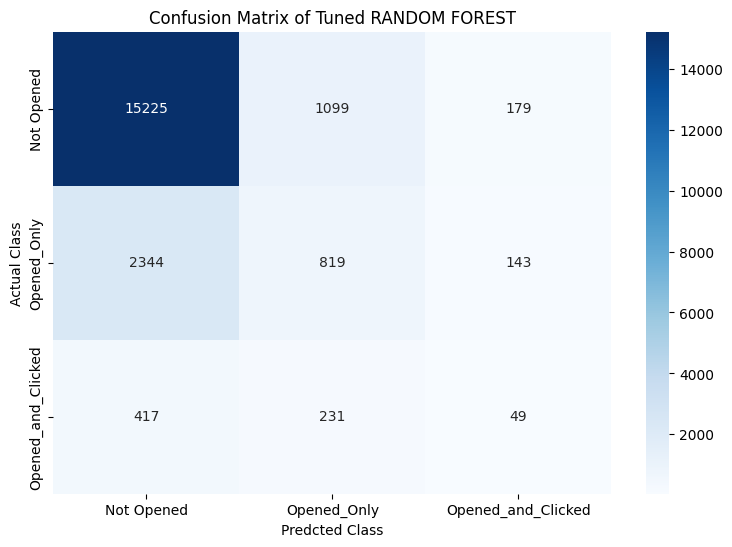

In [ ]:
# Get scores like precision,recall, f1 score,roc_auc_score, confusion matrix
  # precision,
ref_test_precision = precision_score(y_test,y_test_grid_rf_pred, average='weighted', zero_division=0)

  # recall,
ref_test_recall = recall_score(y_test,y_test_grid_rf_pred, average='weighted', zero_division=0)

  # f1 score
ref_f1_score = f1_score(y_test,y_test_grid_rf_pred, average='weighted', zero_division=0)

  # roc_auc_score
# Use predict_proba for roc_auc_score in multiclass setting
ref_roc_auc_score = roc_auc_score(y_test, grid_renf_clf.predict_proba(X_test_fixed), multi_class='ovr', average='weighted')

  # confusion matrix
ref_confusion_mat = confusion_matrix(y_test,y_test_grid_rf_pred)

  # Printing all these matrices
print('Precision score of RANDOM FOREST:',ref_test_precision)
print(' ')
print('Recall score of RANDOM FOREST:', ref_test_recall)
print(' ')
print('F1 score of RANDOM FOREST: ', ref_f1_score)
print(' ')
print('ROC AUC score of RANDOM FOREST: ',ref_roc_auc_score)
print(' ')
print('Confusion matrix of RANDOM FOREST model \n:',ref_confusion_mat)
print(' ')
labels = ['Not Opened','Opened_Only','Opened_and_Clicked']

# plotting confusion matrix through heatmap
plt.figure(figsize = (9,6))
sns.heatmap(ref_confusion_mat,cmap = 'Blues', annot = True, fmt='d', xticklabels = labels, yticklabels = labels)
plt.ylabel('Actual Class')
plt.xlabel('Predcted Class')
plt.title('Confusion Matrix of Tuned RANDOM FOREST',fontsize = 12)
plt.show()

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV (Grid Search with Cross-Validation) is a hyperparameter tuning technique in machine learning. It helps find the best combination of model parameters that result in the highest performance on your dataset.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After hyperparameter tuning, the Random Forest model showed a slight improvement in test performance with a higher F1 score and ROC AUC. It also reduced overfitting by lowering the training accuracy from 99.98% to 96.10%, improving generalization to unseen data.

#### 3. Explain each evaluation metric's indication towards business and the business impact of the ML model used.

The evaluation metrics collectively show how well the model predicts user engagement with emails. Precision ensures marketing efforts are targeted at genuinely responsive users, minimizing waste. Recall helps capture most of the engaged audience, increasing campaign reach. The F1 score balances both, indicating overall reliability. A high ROC AUC reflects the model's ability to distinguish between user behaviors, aiding better personalization. The confusion matrix highlights specific misclassifications, guiding refinements. Together, these metrics demonstrate that the model can effectively support data-driven decisions, improve campaign performance, and boost customer engagement, ultimately enhancing marketing ROI.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm
# Building decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, recall_score

# Custom recall scorer
recall = make_scorer(recall_score, average='weighted', zero_division=0)

dtc = DecisionTreeClassifier()
decision_tree_model = GridSearchCV(dtc, param_grid = {'max_depth': [2,4,6,8],
                                                      'min_samples_leaf': [2,4,6,8,10],
                                                      'min_samples_split':[2,4,6,8,10]},
                                   scoring = recall, # Use the custom recall scorer
                                   cv = 3,
                                   n_jobs = -1)
decision_tree_model.fit(X_train_smt,y_train_smt)

GridSearchCV(cv=3, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'max_depth': [2, 4, 6, 8],
                         'min_samples_leaf': [2, 4, 6, 8, 10],
                         'min_samples_split': [2, 4, 6, 8, 10]},
             scoring=make_scorer(recall_score, response_method='predict', average=weighted, zero_division=0))

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

A Decision Tree Classifier is a supervised machine learning algorithm used for classification tasks. It works by splitting the dataset into branches based on feature values, forming a tree-like structure where:

* Each internal node represents a decision on a feature.

* Each branch represents an outcome of the decision.

* Each leaf node represents a class label (final prediction).

In [ ]:
# Visualizing evaluation Metric Score chart
decision_tree_model.best_estimator_
decision_tree_model.best_params_
decision_tree_model.best_score_

np.float64(0.6293598348856166)

In [ ]:
# Getting train and test predicted values
y_train_dtc_pred = decision_tree_model.predict(X_train_smt)
y_test_dtc_pred = decision_tree_model.predict(X_test_fixed)

# Getting the training and testing accuracy
dtc_training_accuracy = accuracy_score(y_train_smt,y_train_dtc_pred)
dtc_testing_accuracy = accuracy_score(y_test, y_test_dtc_pred)

print('Training accuracy of decision tree classifier:',dtc_training_accuracy)
print('Testing accuracy of decision tree classifier:',dtc_testing_accuracy)

Training accuracy of decision tree classifier: 0.6439460950101462
Testing accuracy of decision tree classifier: 0.7272017945967034


Precision score of Decision Tree model: 0.7573918121014485
 
Recall score of Decision Tree model: 0.7272017945967034
 
F1 score of Decision Tree model:  0.7379759931724585
 
ROC AUC score of Decision Tree model:  0.7305362548409955
 
Confusion matrix of Decision Tree model 
: [[13947  1268  1288]
 [ 1811   718   777]
 [  269   181   247]]
 


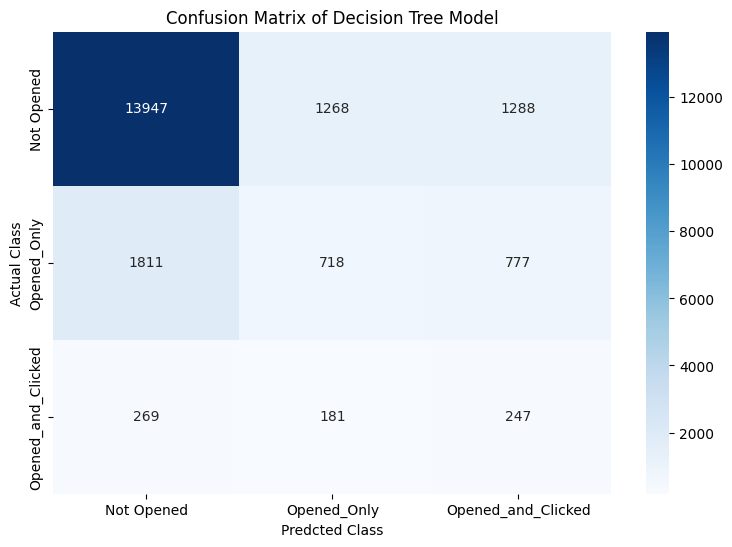

In [ ]:
# Get scores like precision,recall, f1 score,roc_auc_score, confusion matrix
  # precision,
dt_test_precision = precision_score(y_test,y_test_dtc_pred, average='weighted', zero_division=0)

  # recall,
dt_test_recall = recall_score(y_test,y_test_dtc_pred, average='weighted', zero_division=0)

  # f1 score
dt_f1_score = f1_score(y_test,y_test_dtc_pred, average='weighted', zero_division=0)

  # roc_auc_score
# Use predict_proba for roc_auc_score in multiclass setting
dt_roc_auc_score = roc_auc_score(y_test, decision_tree_model.predict_proba(X_test_fixed), multi_class='ovr', average='weighted')


  # confusion matrix
dt_confusion_mat = confusion_matrix(y_test,y_test_dtc_pred)

  # Printing all these matrices
print('Precision score of Decision Tree model:',dt_test_precision)
print(' ')
print('Recall score of Decision Tree model:', dt_test_recall)
print(' ')
print('F1 score of Decision Tree model: ', dt_f1_score)
print(' ')
print('ROC AUC score of Decision Tree model: ',dt_roc_auc_score)
print(' ')
print('Confusion matrix of Decision Tree model \n:',dt_confusion_mat)
print(' ')
labels = ['Not Opened','Opened_Only','Opened_and_Clicked']

# plotting confusion matrix through heatmap
plt.figure(figsize = (9,6))
sns.heatmap(dt_confusion_mat,cmap = 'Blues', annot = True, fmt='d', xticklabels = labels, yticklabels = labels)
plt.ylabel('Actual Class')
plt.xlabel('Predcted Class')
plt.title('Confusion Matrix of Decision Tree Model',fontsize = 12)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

##### Which hyperparameter optimization technique have you used and why?

GridSearchCV (Grid Search with Cross-Validation) is a hyperparameter tuning technique in machine learning. It helps find the best combination of model parameters that result in the highest performance on your dataset.



### ML MODEL - 4

In [ ]:
# Import xgboost
from xgboost import XGBClassifier

# Fitting XGboost
xgb = XGBClassifier(class_weight = 'balanced',parameters = {'max_depth':7,'eta':1,'silent':1,'eval_metric':'auc'},random_state = 42)
xgb.fit(X_train_smt,y_train_smt)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              class_weight='balanced', colsample_bylevel=None,
              colsample_bynode=None, colsample_bytree=None, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Train and test prediction
y_train_xgb_pred = xgb.predict(X_train_smt)
y_test_xgb_pred = xgb.predict(X_test_fixed)


# gettig training and testing accuracy
xgb_training_accuracy = accuracy_score(y_train_xgb_pred,y_train_smt)
xgb_testing_accuracy = accuracy_score(y_test_xgb_pred,y_test)

print(f'Training Accuracy of XGBClassifier: {xgb_training_accuracy}')
print(f'Testing Accuracy of XGBClassifier: {xgb_testing_accuracy}')

Training Accuracy of XGBClassifier: 0.84931578125813
Testing Accuracy of XGBClassifier: 0.8020579342631425


Precision score of XGBoost model: 0.7477964531971016
 
Recall score of XGBoost model: 0.8020579342631425
 
F1 score of XGBoost model:  0.7614635342102781
 
ROC AUC score of XGBoost model:  0.7653782022828469
 
Confusion matrix of XGBoost model 
: [[15833   582    88]
 [ 2631   580    95]
 [  499   164    34]]
 


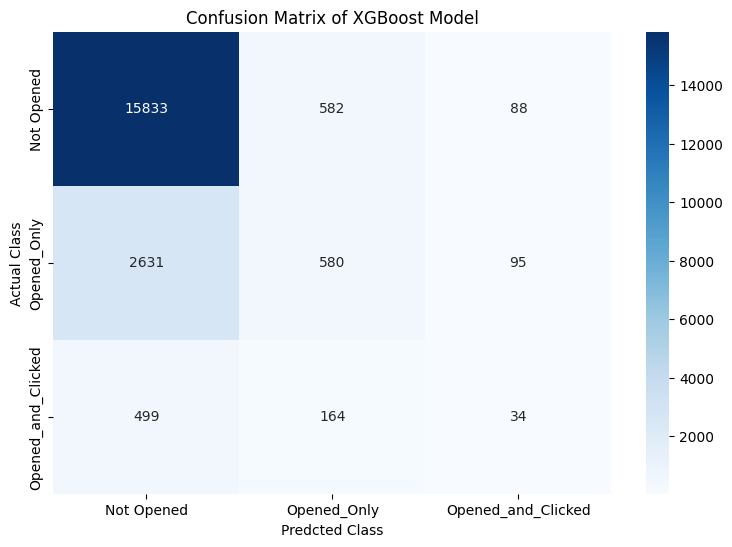

In [ ]:
# Get scores like precision,recall, f1 score,roc_auc_score, confusion matrix
  # precision,
xg_test_precision = precision_score(y_test,y_test_xgb_pred, average='weighted', zero_division=0)

  # recall,
xg_test_recall = recall_score(y_test,y_test_xgb_pred, average='weighted', zero_division=0)

  # f1 score
xg_f1_score = f1_score(y_test,y_test_xgb_pred, average='weighted', zero_division=0)

  # roc_auc_score
# Use predict_proba for roc_auc_score in multiclass setting
xg_roc_auc_score = roc_auc_score(y_test, xgb.predict_proba(X_test_fixed), multi_class='ovr', average='weighted')

  # confusion matrix
xg_confusion_mat = confusion_matrix(y_test,y_test_xgb_pred)

  # Printing all these matrices
print('Precision score of XGBoost model:',xg_test_precision)
print(' ')
print('Recall score of XGBoost model:', xg_test_recall)
print(' ')
print('F1 score of XGBoost model: ', xg_f1_score)
print(' ')
print('ROC AUC score of XGBoost model: ',xg_roc_auc_score)
print(' ')
print('Confusion matrix of XGBoost model \n:',xg_confusion_mat)
print(' ')
labels = ['Not Opened','Opened_Only','Opened_and_Clicked']

# plotting confusion matrix through heatmap
plt.figure(figsize = (9,6))
sns.heatmap(xg_confusion_mat,cmap = 'Blues', annot = True, fmt='d', xticklabels = labels, yticklabels = labels)
plt.ylabel('Actual Class')
plt.xlabel('Predcted Class')
plt.title('Confusion Matrix of XGBoost Model',fontsize = 12)
plt.show()

XGBoost (Extreme Gradient Boosting) is a powerful, efficient, and scalable machine learning algorithm based on gradient boosting. It builds an ensemble of decision trees sequentially, where each new tree focuses on correcting the errors of the previous ones. XGBoost uses techniques like regularization, tree pruning, and parallel computation, which helps improve performance and reduce overfitting. It’s especially popular in data science competitions and structured/tabular datasets.


# **Evaluation Matrix**

In [ ]:
# explaining evaluation matrix
Models = ['Logistic Regression','Random Forest','Random Forest tuning','Decision Tree Classifier', 'XGBoost Classifier']
train_accuracy = [train_accuracy, rf_training_accuracy, ref_training_accuracy,dtc_training_accuracy, xgb_training_accuracy]
test_accuracy = [test_accuracy, rf_testing_accuracy, ref_testing_accuracy,dtc_testing_accuracy, xgb_testing_accuracy]
precision_score = [log_test_precision, rf_test_precision, ref_test_precision,dt_test_precision, xg_test_precision]
recall_score = [log_test_recall, rf_test_recall, ref_test_recall,dt_test_recall,xg_test_recall]
f1_score = [log_f1_score, rf_f1_score, ref_f1_score,dt_f1_score, xg_f1_score]
roc_auc_score = [log_roc_auc_score, rf_roc_auc_score, ref_roc_auc_score,dt_roc_auc_score, xg_roc_auc_score]

data = {'Classification Models':Models,'Training Accuracy':train_accuracy,'Testing Accuracy':test_accuracy,
        'Precision Score':precision_score,'Recall Score':recall_score,'F1 Score':f1_score,'ROC-AUC Score':roc_auc_score}

evaluation_matrix = pd.DataFrame(data)
evaluation_matrix

,Classification Models,Training Accuracy,Testing Accuracy,Precision Score,Recall Score,F1 Score,ROC-AUC Score
0,Logistic Regression,0.612900,0.689749,0.729584,0.689749,0.705813,0.658844
1,Random Forest,0.999844,0.786404,0.742759,0.786404,0.759504,0.740985
2,Random Forest tuning,0.959667,0.784795,0.747179,0.784795,0.762070,0.752258
3,Decision Tree Classifier,0.643946,0.727202,0.757392,0.727202,0.737976,0.730536
4,XGBoost Classifier,0.849316,0.802058,0.747796,0.802058,0.761464,0.765378


###1. Which Evaluation metrics did you consider for a positive business impact and why?

For this business case (likely predicting customer email engagement), the most relevant metrics are:

Recall Score: Helps identify as many truly engaged users as possible, reducing missed opportunities (false negatives).

Precision Score: Ensures that users identified as engaged actually are, minimizing wasted resources.

F1 Score: A balance between precision and recall, especially important when both false positives and false negatives have costs.

ROC-AUC Score: Reflects the model’s ability to distinguish between the classes overall — valuable for understanding model confidence.

These metrics directly align with business goals like improving campaign effectiveness, user targeting, and customer retention.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

The choosen model is XGBOOST Classifier.


Highest Testing Accuracy: 0.80206, better than all others.

Best Recall Score: 0.80206 — captures more of the true positives, which is key for reaching engaged users.

Strong F1 Score: 0.7615, showing a balanced trade-off.

Best ROC-AUC Score: 0.7654, indicating strong class separation.

Although Random Forest with tuning had a slightly higher F1 Score (0.7621), XGBoost outperformed across more important metrics for this business context — especially in recall and AUC, making it the best overall model.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The XGBoost Classifier is an advanced ensemble method based on gradient boosting. It builds decision trees sequentially and corrects previous errors, allowing it to handle complex patterns and non-linear relationships effectively. It also includes built-in regularization to reduce overfitting.

MODEL EXPLAINABILITY

In [ ]:
# Install shap
!pip install shap

In [ ]:
# Import dependancy
from shap import force_plot
from shap import TreeExplainer
from shap import summary_plot

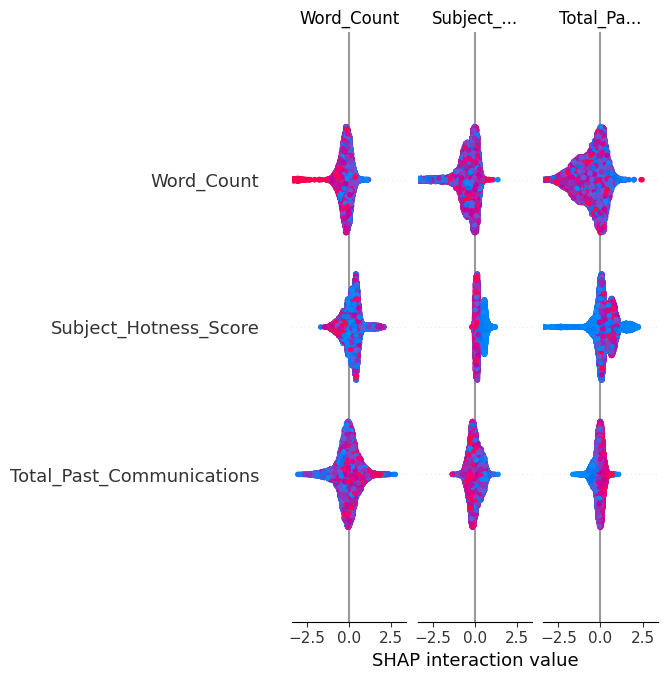

In [ ]:
# plotting summary plot
explainer = TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_fixed)
summary_plot(shap_values, X_test_fixed, cmap='viridis')

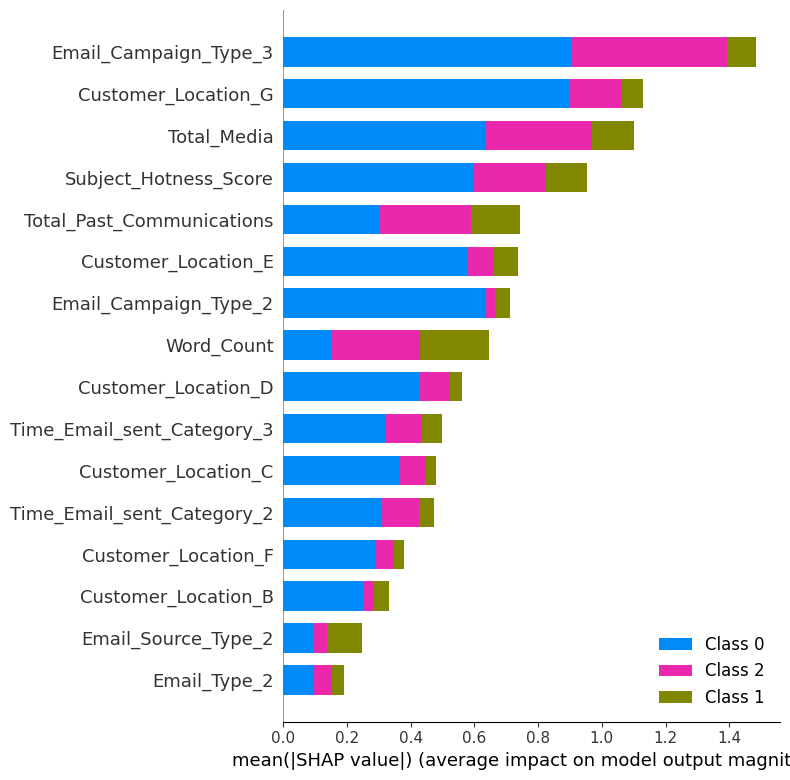

In [ ]:
# Shap summary_plot with bar
explainer = TreeExplainer(xgb)
shap_values = explainer.shap_values(X_train_smt)
summary_plot(shap_values, X_train_smt, plot_type="bar")

# **Conclusion**

In this project, multiple classification models were developed and evaluated to predict the email engagement status of users (Not Opened, Opened Only, Opened and Clicked). Various machine learning algorithms were implemented, including Logistic Regression, Decision Tree, Random Forest (with and without hyperparameter tuning), and XGBoost Classifier. Among these, XGBoost outperformed all models with the highest testing accuracy (80.201%) and strong evaluation metrics such as F1 Score (0.7612), Precision (0.748), and ROC-AUC Score (0.765). These metrics indicate that XGBoost offers the best balance between precision and recall, which is crucial in business scenarios involving targeted marketing and customer engagement.

Furthermore, SHAP explainability techniques were applied to interpret model decisions and identify the most influential features such as Word_Count, Subject_Hotness_Score, and Total_Past_Communications. These insights can be used to fine-tune future email campaigns for improved customer interaction.

Overall, the final model not only achieves strong performance but also delivers actionable insights, helping drive better business decisions through data-driven marketing strategies.